## Modeling with K-Nearest Neighbors Ball Tree Algorithm for Red Wine Quality Prediction (Classification Problem)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#split Data Train and Test libs
#modeling libs
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.neighbors import KNeighborsClassifier

In [2]:
redwine_df = pd.read_csv('../winequality-red-clean.csv', sep=',')
redwine_df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
295,-0.310991,-0.555366,0.286178,0.475466,-0.074189,1.493391,0.487613,0.397141,-0.044462,-0.018613,-0.114652,5
1065,-0.432422,-0.968257,0.233878,-0.796196,-0.121157,1.171312,0.725676,0.257434,1.018258,-0.172805,-0.898763,6
1383,-1.100295,0.034478,-1.073614,-0.449379,-0.872647,1.493391,0.011488,-1.063956,0.451474,1.446214,-0.114652,6
1316,-0.675285,-0.850288,0.233878,-0.449379,-1.201424,-0.009646,-0.498646,-1.162915,-0.611246,0.906541,0.865486,8
383,1.267617,-0.673335,1.489071,0.937888,-0.262062,0.741872,0.351577,1.677783,-1.178030,1.908790,-0.506707,6


In [3]:
redwine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1458 non-null   float64
 1   volatile acidity      1458 non-null   float64
 2   citric acid           1458 non-null   float64
 3   residual sugar        1458 non-null   float64
 4   chlorides             1458 non-null   float64
 5   free sulfur dioxide   1458 non-null   float64
 6   total sulfur dioxide  1458 non-null   float64
 7   density               1458 non-null   float64
 8   pH                    1458 non-null   float64
 9   sulphates             1458 non-null   float64
 10  alcohol               1458 non-null   float64
 11  quality               1458 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 136.8 KB


# Simple Descriptive Analysis

In [4]:
redwine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1.458000e+03,1.458000e+03,1.458000e+03,1458.000000,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1458.000000
mean,-8.382260e-16,1.462022e-17,-2.046831e-16,0.000000,5.750620e-16,-1.949363e-17,-8.772133e-17,-2.074122e-14,8.869601e-16,1.072150e-16,3.703789e-16,5.646776
std,1.000343e+00,1.000343e+00,1.000343e+00,1.000343,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,0.801119
min,-2.011030e+00,-2.383882e+00,-1.387413e+00,-1.374224,-2.046850e+00,-1.512683e+00,-1.280852e+00,-3.037311e+00,-3.090926e+00,-2.408593e+00,-1.976915e+00,3.000000
25%,-7.360008e-01,-7.913033e-01,-9.167153e-01,-0.564985,-5.438703e-01,-8.685246e-01,-7.707176e-01,-6.506581e-01,-6.820941e-01,-7.124783e-01,-8.987626e-01,5.000000
50%,-2.502753e-01,-2.450604e-02,-7.992024e-02,-0.218168,-1.211572e-01,-2.243658e-01,-2.605836e-01,-1.033665e-02,-9.038221e-03,-1.728053e-01,-2.126658e-01,6.000000
75%,5.390288e-01,6.538146e-01,8.091745e-01,0.244255,3.485241e-01,6.345126e-01,4.876130e-01,6.299848e-01,5.931697e-01,5.981561e-01,6.694587e-01,6.000000
max,3.149804e+00,3.042683e+00,2.744263e+00,4.984085,6.783157e+00,3.425867e+00,3.446391e+00,3.191270e+00,3.072849e+00,3.990386e+00,3.119804e+00,8.000000


### the scater plot of the data below, describes the relationship between the density and alcohol content of the red wine.
the data shows that the density of the red wine is inversely proportional to the alcohol content. The higher the alcohol content, the lower the density of the red wine.

<Axes: xlabel='density', ylabel='alcohol'>

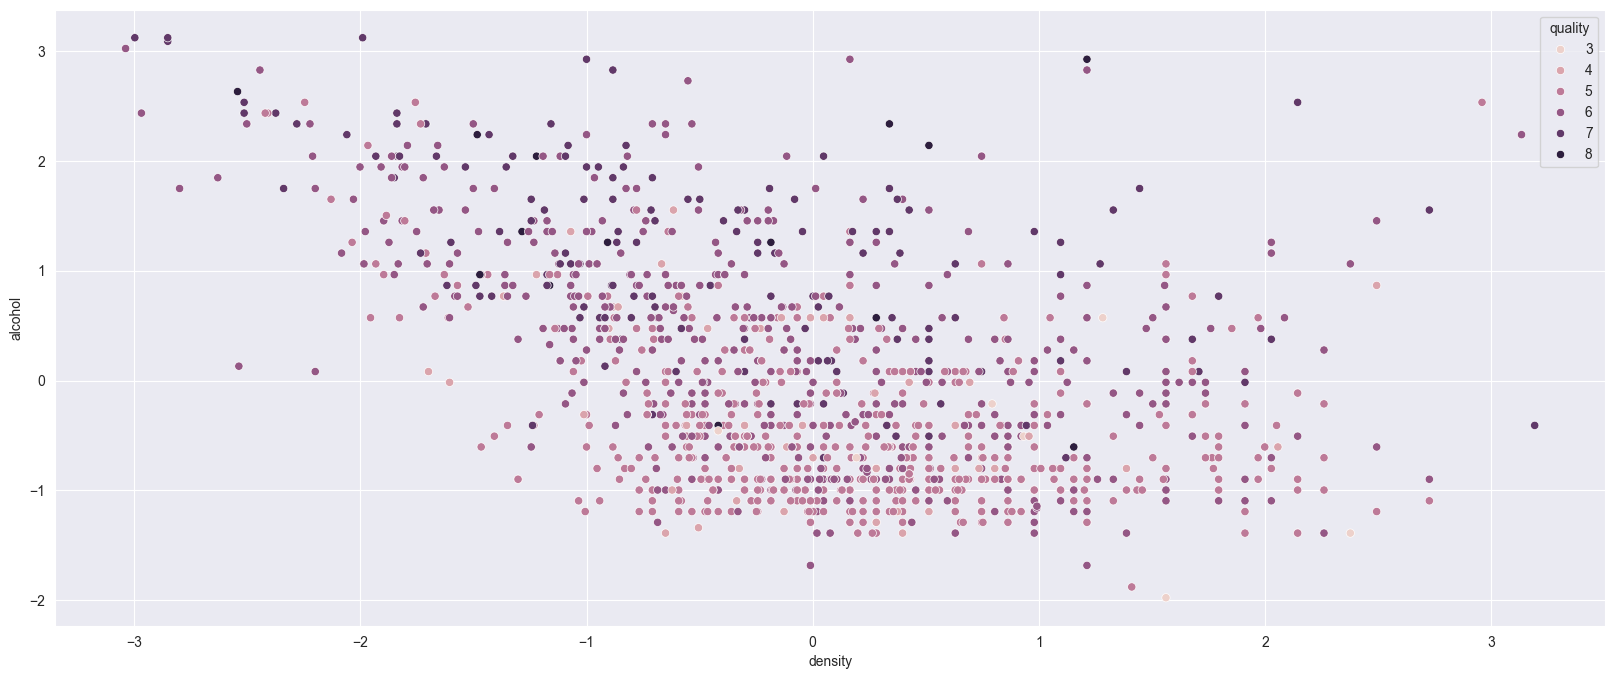

In [5]:
plt.figure(figsize=(20, 8))
sns.scatterplot(x='density', y='alcohol', data= redwine_df, hue='quality')

#Interesting Correlations:

Fixed acidity and pH have a strong negative correlation (-0.68), meaning that as fixed acidity increases, pH decreases.

Alcohol and quality have a moderately positive correlation (0.48), suggesting that higher alcohol content is associated with better quality.

Free sulfur dioxide and total sulfur dioxide have a high positive correlation (0.67), which makes sense since they are related chemically.

Low or Negligible Correlations: Some variables, like chlorides and citric acid, show almost no correlation (0.056), meaning they don’t have a significant linear relationship.

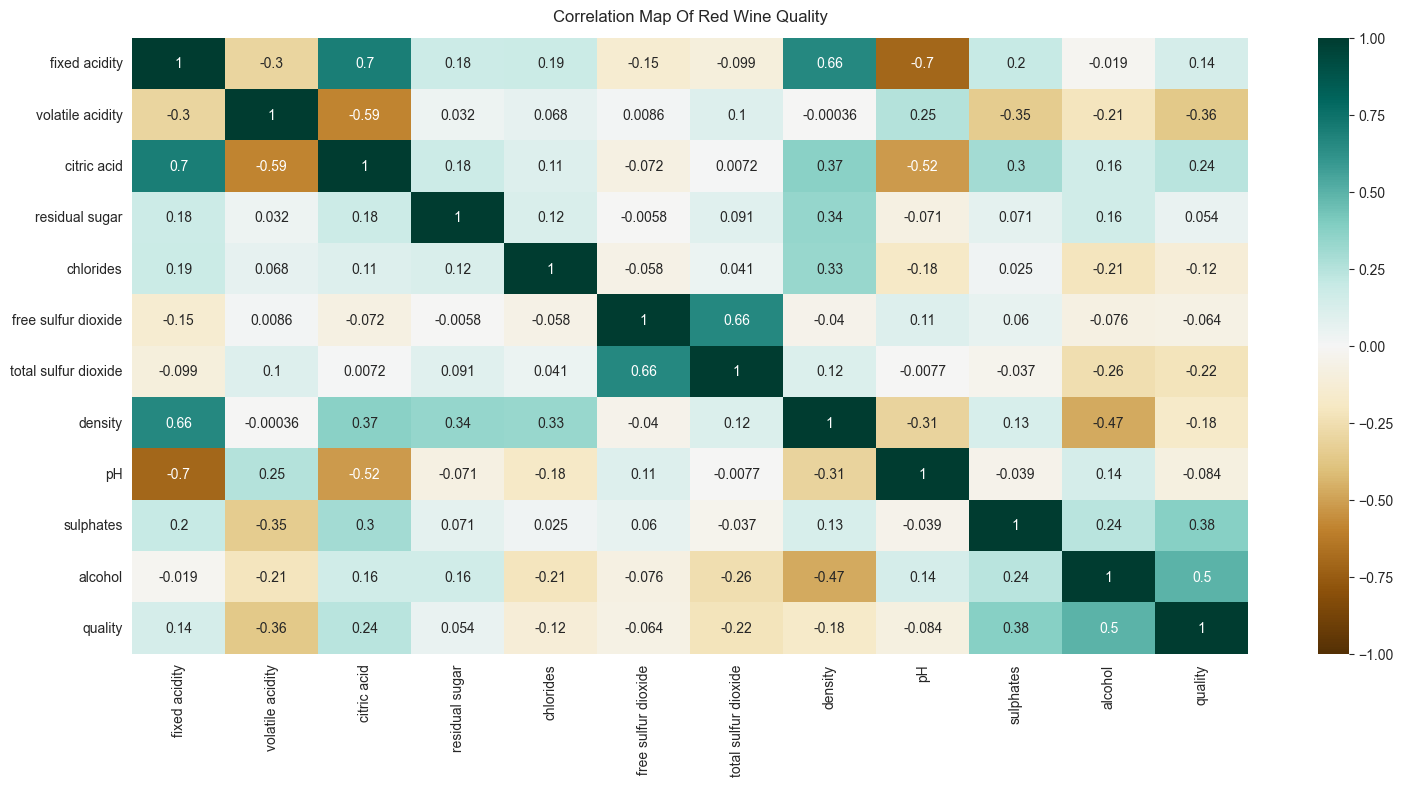

In [6]:
plt.figure(figsize=(18, 8))
sns.heatmap(redwine_df.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
plt.title('Correlation Map Of Red Wine Quality', fontdict={'fontsize':12}, pad=12);

# PreProcessing

In [7]:
redwine_df['quality'].unique()

array([5, 6, 7, 4, 8, 3], dtype=int64)

In [8]:
quality_counts = redwine_df['quality'].value_counts()
quality_counts

quality
5    617
6    586
7    185
4     47
8     16
3      7
Name: count, dtype: int64

In [9]:
redwine_df.sample(6)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
456,1.449764,-0.732319,1.122973,-0.333774,2.039377,-0.009646,0.181533,0.746407,-2.028206,1.292021,-0.702735,6
1222,-0.675285,0.771783,-1.230513,-0.680590,-0.168125,-0.868525,-1.076798,-0.493488,0.168082,-1.946017,-0.898763,5
459,2.542647,0.447369,1.175272,2.209550,0.865174,-1.083244,-1.008780,2.492738,-0.469550,0.752348,1.453569,6
718,-0.371707,0.211432,-0.969015,0.128649,1.522727,-0.117006,0.079506,0.222508,-0.540398,0.135579,-0.800749,6
870,0.114019,-0.319428,0.024679,-0.564985,-1.107488,0.312433,-0.192566,-0.895144,-1.107182,1.600406,0.669459,6
1076,-0.796717,-0.555366,0.181578,-0.449379,0.160652,-0.975884,-0.158557,-1.896374,0.097234,-1.406344,1.453569,6


*Splitting Data*

In [10]:
X = redwine_df.drop(['quality'], axis = 1)
y = redwine_df['quality']

In [11]:
X.shape

(1458, 11)

In [12]:
y.shape

(1458,)

## *Find Best K-Score*

A large K value has benefits which include reducing the variance due to the noisy data, the side effect being developing a bias due to which the learner tends to ignore the smaller patterns which may have useful insights. The data indicates underfitting.

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score

def find_best_k(X_train, y_train, X_test, y_test, k_range=(1, 50, 1)):
    """
    Finds the best K value for KNeighborsClassifier using cross-validation and records training/testing accuracy.

    Parameters:
    X_train: Features for training the model
    y_train: Labels for training the model
    X_test: Features for testing the model
    y_test: Labels for testing the model
    k_range: A tuple (start, stop, step) representing the range of K values to test

    Returns:
    best_k: The K value that gives the highest cross-validated accuracy score
    best_score: The highest accuracy score
    training_accuracy: List of training accuracy scores for each K value
    testing_accuracy: List of testing accuracy scores for each K value
    """

    # Extract the range of K values to test
    k_values = range(k_range[0], k_range[1], k_range[2])

    # Lists to hold the accuracy scores for each K value
    training_accuracy = []
    testing_accuracy = []
    
    # Loop over the different K values
    for k in k_values:
        # Define the KNN model with current K value
        knn = KNeighborsClassifier(n_neighbors=k)
        # Create a pipeline with MinMaxScaler and KNN
        pipeline = Pipeline([('scaler', MinMaxScaler()), ('knn', knn)])
        
        # Fit the pipeline on the training data
        pipeline.fit(X_train, y_train)
        
        # Predict on the training data
        y_train_pred = pipeline.predict(X_train)
        train_acc = accuracy_score(y_train, y_train_pred)
        training_accuracy.append(train_acc)
        
        # Predict on the testing data
        y_test_pred = pipeline.predict(X_test)
        test_acc = accuracy_score(y_test, y_test_pred)
        testing_accuracy.append(test_acc)
    
    # Get the best K value based on the test accuracy
    best_score = max(testing_accuracy)
    best_k = k_values[testing_accuracy.index(best_score)]

    print(f"Best K: {best_k} with test accuracy: {best_score:.4f}")
    
    return best_k, best_score, training_accuracy, testing_accuracy



Best K: 5 with test accuracy: 0.4444


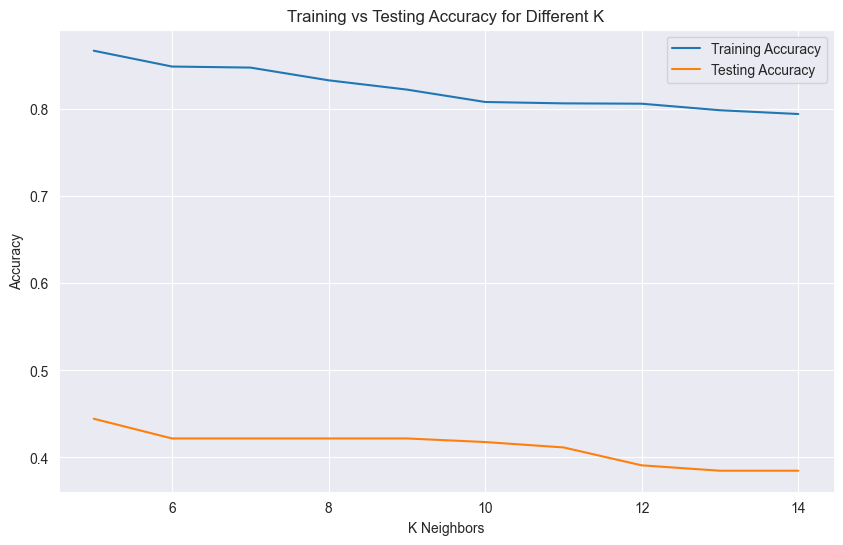

Test Accuracy with K=5 and Ball Tree: 0.5432
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.08      0.40      0.13        10
           5       0.76      0.59      0.67       195
           6       0.69      0.50      0.58       210
           7       0.39      0.61      0.47        61
           8       0.04      0.12      0.06         8

    accuracy                           0.54       486
   macro avg       0.33      0.37      0.32       486
weighted avg       0.65      0.54      0.58       486



In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.333, random_state=42)

# Applying SMOTE with a lower number of neighbors to balance the training data
smote = SMOTE(random_state=0, k_neighbors=3)
X_resampled, Y_resampled = smote.fit_resample(X_train, y_train)

# Finding the best K value using cross-validation on the resampled (balanced) training data
best_k, best_score, training_accuracy, testing_accuracy = find_best_k(X_resampled, Y_resampled, X_test, y_test, k_range=(5, 15, 1))

# Plot training vs testing accuracy for different K values
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(5, 15), y=training_accuracy, label="Training Accuracy")
sns.lineplot(x=range(5, 15), y=testing_accuracy, label="Testing Accuracy")
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy for Different K")
plt.legend()
plt.show()

# Now, use the best K value (from find_best_k function) in your KNN model
knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance', algorithm='ball_tree')

# Create a pipeline that scales the data and applies the KNN classifier
pipe_knn = Pipeline([('scale', MinMaxScaler()), ('knn', knn)])

# Fit the model to the resampled training data
pipe_knn.fit(X_resampled, Y_resampled)

# Make predictions on the test set
y_pred = pipe_knn.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with K={best_k} and Ball Tree: {accuracy:.4f}")

# Display detailed performance metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))


# Modeling

In [15]:

# Create a KNN model using the best K (K=9)
knn = KNeighborsClassifier(n_neighbors=9)

# Create a pipeline to scale the data and apply the KNN classifier
pipe_knn = Pipeline([('scaler', MinMaxScaler()), ('knn', knn)])

# Fit the model to the training data
pipe_knn.fit(X_train, y_train)


Pipeline(steps=[('scaler', MinMaxScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=9))])

*Define Model Using Best K-Score*

In [16]:
# Predict on the test set
y_pred = pipe_knn.predict(X_test)
y_pred


array([5, 5, 6, 6, 6, 6, 6, 7, 5, 6, 5, 5, 5, 5, 6, 7, 6, 5, 6, 5, 7, 6,
       5, 6, 6, 5, 5, 5, 6, 7, 6, 5, 5, 5, 6, 6, 5, 6, 6, 5, 5, 5, 5, 5,
       5, 5, 6, 5, 6, 6, 5, 6, 6, 6, 5, 5, 5, 7, 6, 5, 4, 7, 5, 5, 5, 5,
       6, 5, 6, 5, 6, 6, 6, 5, 5, 6, 5, 5, 6, 6, 5, 6, 6, 6, 6, 6, 5, 6,
       7, 6, 5, 5, 6, 5, 6, 6, 6, 5, 5, 6, 5, 6, 5, 6, 6, 6, 5, 5, 6, 5,
       6, 6, 5, 6, 5, 5, 6, 6, 6, 6, 5, 5, 5, 6, 7, 5, 6, 6, 6, 5, 7, 6,
       5, 6, 6, 5, 7, 5, 5, 7, 6, 5, 5, 5, 6, 6, 6, 6, 6, 5, 6, 5, 5, 5,
       5, 6, 6, 6, 5, 5, 5, 6, 7, 7, 7, 5, 6, 6, 5, 6, 6, 5, 6, 5, 6, 5,
       6, 5, 6, 5, 6, 6, 5, 5, 7, 6, 5, 5, 6, 5, 5, 5, 7, 5, 6, 5, 6, 5,
       6, 6, 6, 5, 7, 7, 5, 6, 6, 6, 6, 6, 5, 5, 5, 6, 5, 6, 5, 6, 5, 7,
       7, 5, 5, 6, 7, 5, 6, 5, 6, 7, 5, 6, 5, 6, 6, 7, 6, 5, 5, 5, 5, 5,
       6, 6, 5, 5, 5, 6, 5, 5, 6, 6, 5, 5, 5, 5, 5, 6, 6, 5, 7, 5, 6, 6,
       5, 6, 5, 6, 7, 5, 6, 6, 6, 5, 5, 5, 6, 6, 5, 6, 6, 5, 6, 6, 6, 6,
       5, 5, 5, 5, 5, 7, 6, 6, 6, 5, 5, 5, 5, 6, 5,

### Key Metrics:
The classification report contains several important evaluation metrics for a classification problem:

1. **Precision**:
   - Precision is the ratio of correctly predicted positive observations to the total predicted positives (true positives / (true positives + false positives)).
   - A **higher precision** means fewer false positives.
   
2. **Recall**:
   - Recall is the ratio of correctly predicted positive observations to all observations in the actual class (true positives / (true positives + false negatives)).
   - A **higher recall** means fewer false negatives.

3. **F1-Score**:
   - The F1-Score is the harmonic mean of precision and recall. It gives a balanced score that considers both precision and recall.
   - F1-Score is useful when you need to balance precision and recall, especially in imbalanced datasets.
   
4. **Support**:
   - Support is the number of actual occurrences of each class in the dataset. It helps to understand how many samples belong to each class.

---

### Breakdown of the Classification Report:

| Label | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 3     | 1.00      | 0.00   | 0.00     | 2       |
| 4     | 0.00      | 0.00   | 0.00     | 10      |
| 5     | 0.66      | 0.75   | 0.70     | 195     |
| 6     | 0.60      | 0.62   | 0.61     | 210     |
| 7     | 0.48      | 0.38   | 0.42     | 61      |
| 8     | 1.00      | 0.00   | 0.00     | 8       |

---

### Observations:
1. **Class 3 and Class 8**:
   - **Precision** is 1.00, meaning when the model predicts class 3 or 8, it is correct. However, **recall** is 0.00, which means the model is not identifying any actual samples of these classes (likely because there are very few samples for these classes: only 2 and 8 respectively). This leads to an **F1-Score** of 0.00.
   
2. **Class 4**:
   - The model has **0.00 precision, recall, and F1-Score** for this class, indicating that the model either did not predict class 4 correctly at all or failed to recognize this class during classification.
   
3. **Class 5 and Class 6**:
   - These are the most frequent classes in the dataset. For class 5, the model achieves a **precision of 0.66** and **recall of 0.75**, which results in an **F1-Score of 0.70**.
   - Similarly, for class 6, the **precision is 0.60**, **recall is 0.62**, and **F1-Score is 0.61**. These scores are relatively decent compared to the other classes, indicating the model is performing better on the more frequent classes.
   
4. **Class 7**:
   - The model struggles with class 7, achieving only **0.48 precision** and **0.38 recall**, resulting in a relatively low **F1-Score of 0.42**.

---

### Overall Metrics:
- **Accuracy**:
  - The overall accuracy is **0.62**, meaning 62% of the predictions are correct. This is the ratio of correctly predicted instances to the total instances.
  
- **Macro Average**:
  - The **macro average** computes the unweighted average across all classes. It gives equal weight to all classes, regardless of their frequency. Here, the **macro avg precision, recall, and F1-Score** are low because the model struggles with the rare classes (like 3, 4, and 8).
  
- **Weighted Average**:
  - The **weighted average** computes the average across all classes, weighted by the number of instances in each class. It accounts for the imbalance in the dataset. Here, the **weighted avg F1-Score is 0.60**, meaning that the model’s performance is somewhat balanced, but it still struggles with certain classes.

---

### Conclusions:
- The model performs reasonably well for the frequent classes (5 and 6) but struggles with rare classes (3, 4, and 8).
- There is a class imbalance, which may be affecting the model’s performance.
- The low recall for some classes indicates the model is missing out on true positives for those classes, likely due to the dataset imbalance.

*Cross Validation*

In [17]:
from sklearn.metrics import classification_report

# Calculate classification report with zero_division parameter
print(classification_report(y_test, y_pred, zero_division=1))


              precision    recall  f1-score   support

           3       1.00      0.00      0.00         2
           4       0.00      0.00      0.00        10
           5       0.66      0.75      0.70       195
           6       0.60      0.62      0.61       210
           7       0.48      0.38      0.42        61
           8       1.00      0.00      0.00         8

    accuracy                           0.62       486
   macro avg       0.62      0.29      0.29       486
weighted avg       0.61      0.62      0.60       486



Now, see if the HyperParameter Tuning process can boost until getting the maximum score.

In [18]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation on the training set (with 5 folds)
cv_scores = cross_val_score(pipe_knn, X_train, y_train, cv=5)

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")


Cross-Validation Scores: [0.63589744 0.55384615 0.57216495 0.56185567 0.58762887]
Mean CV Accuracy: 0.5823


# HyperParameter Tuning

In [19]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'knn__weights': ['uniform', 'distance'],
    'knn__leaf_size': [5,10,15, 20, 30, 40]
}

# Perform GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(pipe_knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


Best parameters: {'knn__leaf_size': 5, 'knn__weights': 'distance'}
Best cross-validation score: 0.6429
